# Image Processing Pipeline Demonstration

This notebook demonstrates the full step-by-step process for a single image, showing the original image, filtered versions, and the final binarized results.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd

sys.path.append('src')
import noise_filter

# Create output directory for demo images
output_dir = Path("data/output_demo")
output_dir.mkdir(exist_ok=True)

def show_img(img, title="Image", cmap="gray"):
    plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

## 1. Load Data
Select one image from the training set and its corresponding mask for the example.

Processing: palsar_2.png


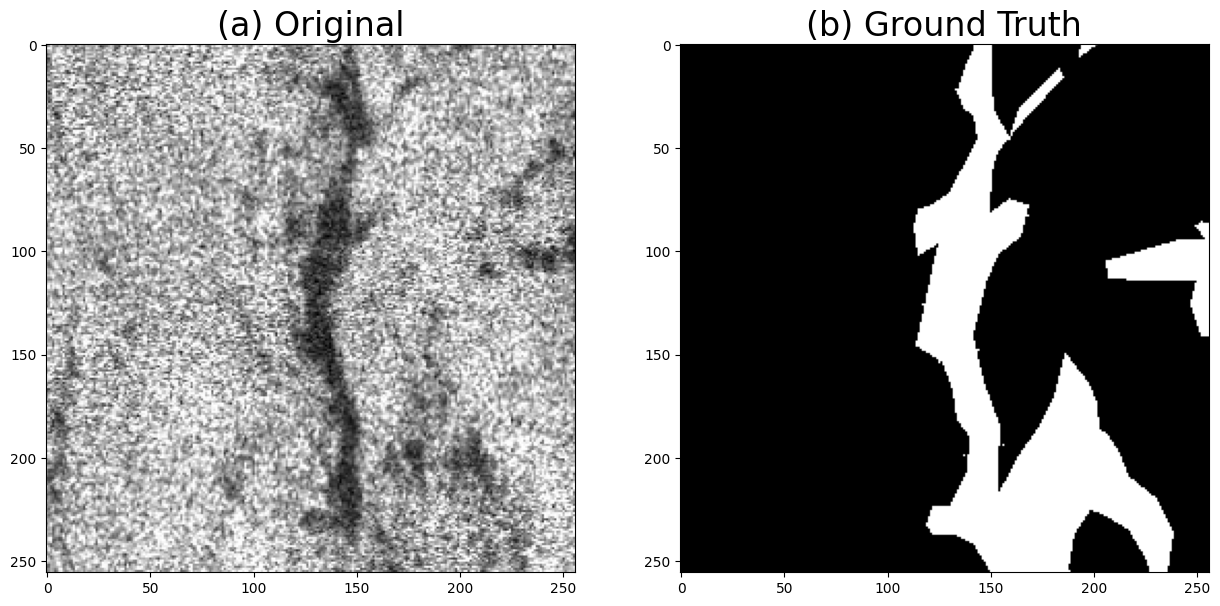

True

In [29]:
img_dir = Path("data/images/images/train")
mask_dir = Path("data/masks/masks/train")

# Pick the first image found
sample_path = img_dir / "palsar_2.png"
# sample_path = next(img_dir.glob("*.png"))
mask_path = mask_dir / sample_path.name

original = noise_filter.load_image(sample_path)
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

print(f"Processing: {sample_path.name}")
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(original, cmap='gray')
ax[0].set_title("(a) Original", fontsize=24)
ax[1].imshow(mask, cmap='gray')
ax[1].set_title("(b) Ground Truth", fontsize=24)
plt.savefig(output_dir/"dataset_example.png", dpi=300, bbox_inches='tight')
plt.show()
cv2.imwrite(str(output_dir / "01_original.png"), original)
cv2.imwrite(str(output_dir / "02_mask.png"), mask)

## 2. Filtering
Applying different noise reduction filters.

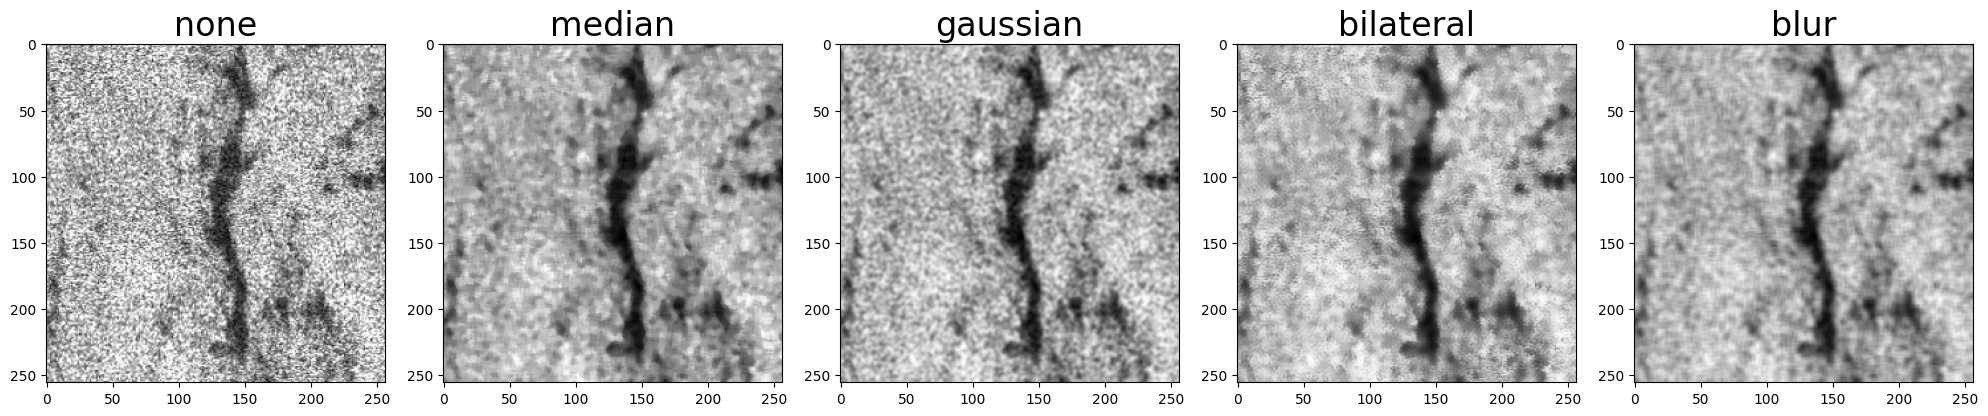

In [33]:
filters = ["none", "median", "gaussian", "bilateral", "blur"]
filtered_images = {}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, f_type in enumerate(filters):
    img_f = noise_filter.filter_img(original, f_type)
    filtered_images[f_type] = img_f
    axes[i].imshow(img_f, cmap='gray')
    axes[i].set_title(f"{f_type}", fontsize=24)
    cv2.imwrite(str(output_dir / f"03_filtered_{f_type}.png"), img_f)
    
plt.savefig(output_dir/"filter_example.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 3. Binarization
Applying binarization with optimal threshold found.

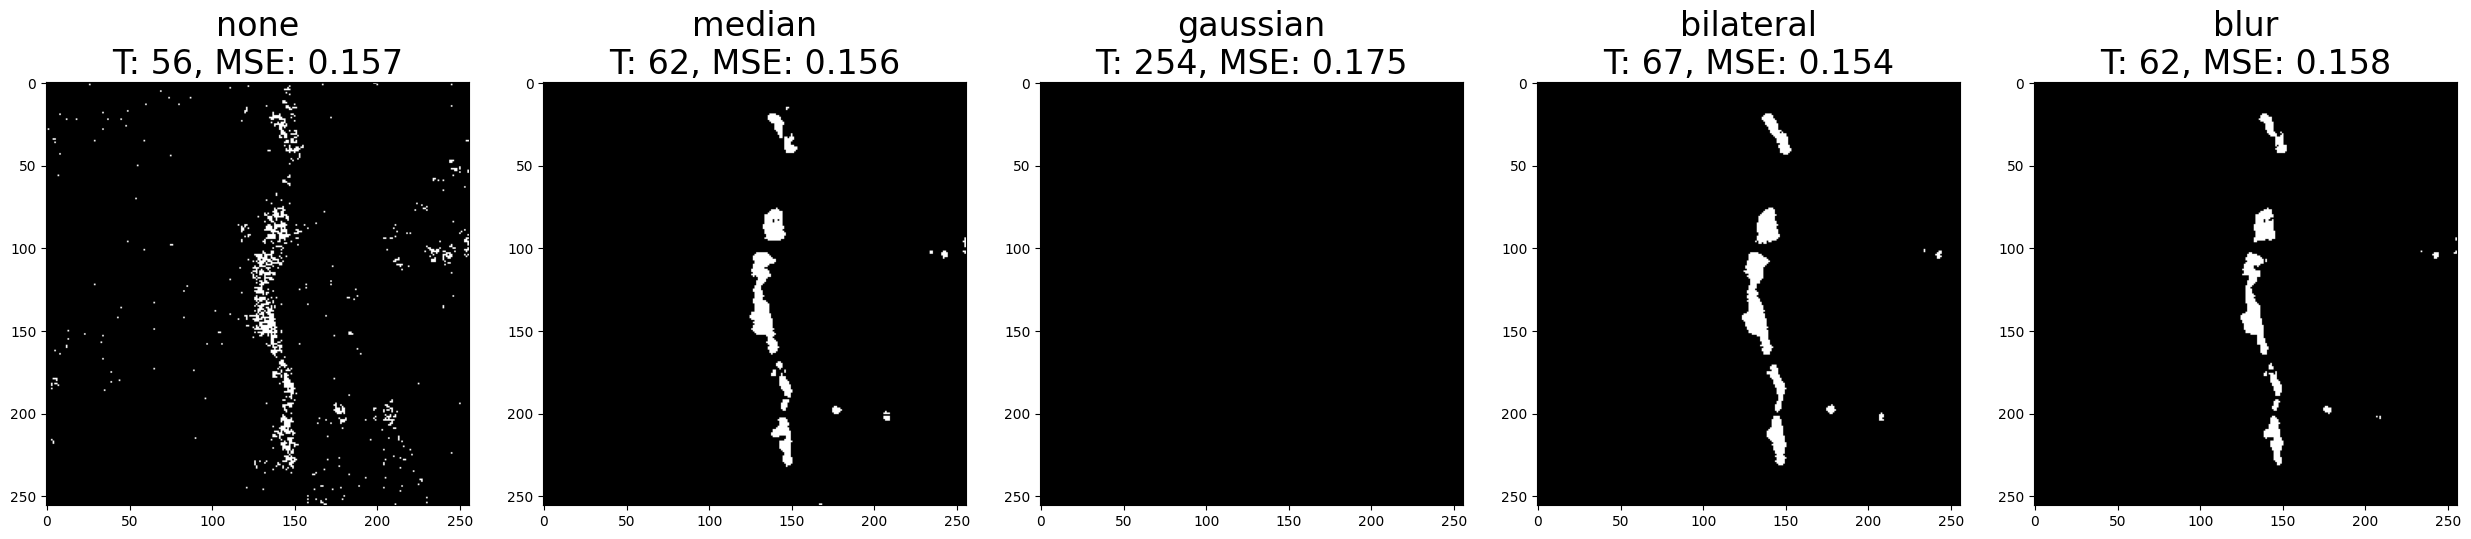

In [35]:
try:
    df_results = pd.read_csv("experiment_results.csv")
    # Get optimal params for each filter type
    best_params = df_results.groupby("filter_type")[["threshold", "inverse"]].first().to_dict('index')
except FileNotFoundError:
    print("Warning: experiment_results.csv not found. Using default threshold 127.")
    best_params = {f: {"threshold": 127, "inverse": False} for f in filters + ["none"]}

fig, axes = plt.subplots(1, 5, figsize=(25, 5))


for i, f_type in enumerate(filters):
    img_to_bin = original if f_type == "none" else filtered_images[f_type]
    params = best_params.get(f_type, {"threshold": 127, "inverse": False})
    
    binarized = noise_filter.binarization(img_to_bin, params['threshold'], inverse=params['inverse'])
    
    mse = noise_filter.mean_squared_error(binarized, mask)
    
    axes[i].imshow(binarized, cmap='gray')
    axes[i].set_title(f"{f_type}\nT: {params['threshold']}, MSE: {mse:.3f}", fontsize=24)
    cv2.imwrite(str(output_dir / f"04_binarized_{f_type}.png"), binarized)

plt.savefig(output_dir/"binarization_example.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()